# APL-Diffusion — Section 6.1 Experiment

**Paper:** Jin, Xu, Yang (2025) — *Adaptive Partitioning and Learning for Stochastic Control of Diffusion Processes*, arXiv:2512.14991

This notebook imports `apl_diffusion_full.py` as a library and runs each step of the experiment independently. Nothing executes on import — every cell is opt-in.

**File must be in the same directory as this notebook.**

---
### Structure
| Cell | What it does |
|------|-------------|
| 1 | Imports and configuration |
| 2 | Bellman solver → V\*(x₀) |
| 3 | MC constant-policy lower bound |
| 4 | Run APL-Diffusion experiments |
| 5 | Partition heatmap |
| 6 | Regret plots + slope summary |

## Cell 1 — Imports and configuration

In [7]:
import time
import numpy as np

from aaro_again import (
    reward_6_1, reward_quadratic_asymmetric,
    reward_quadratic_shifted, reward_quartic,
    AdaDiffEnvironment, APLDiffusion, Experiment,
    BellmanSolverScalar, compute_vstar_gh,
    run_experiments, cumulative_regret, regret_slope,
    plot_all, plot_partition_heatmap,
    N_EPS, EP_LEN, STARTING_STATE,
)

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        PROBLEM DEFINITION                              ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║                                                                        ║
# ║  1-D episodic stochastic control, H=10 steps, K=2000 episodes.         ║
# ║                                                                        ║
# ║  Dynamics (O-U diffusion):                                             ║
# ║    X_{h+1} = X_h + (0.05 - 0.1·X_h + 0.01·A_h)·Δ + 0.1·√Δ·B_h       ║
# ║    B_h ~ N(0,1),  Δ=1,  x₁=4,  state clipped to [-50, 50]             ║
# ║                                                                        ║
# ║  Reward family — all of the form  R_h = mean(x,a) + N(0, 0.01):        ║
# ║                                                                        ║
# ║   reward_6_1                  -(x-a)²           a*(x) = x   m=1       ║
# ║   reward_quadratic_asymmetric -(x-a)²·(1+|x|)   a*(x) = x   m=1       ║
# ║   reward_quadratic_shifted    -(x-a-0.5)²        a*(x) = x-½ m=1       ║
# ║   reward_quartic              -(x-a)⁴            a*(x) = x   m=3       ║
# ║                                                                        ║
# ║  All rewards are NEGATIVE — agent MINIMISES distance to optimal.       ║
# ║  Optimal action a*(x)=x lies in the INTERIOR of the action space,      ║
# ║  so the partition naturally concentrates around the diagonal a=x.      ║
# ║                                                                        ║
# ║  Action spaces:                                                        ║
# ║   reward_6_1:        [0, 10]   (preserves paper action space)          ║
# ║   all others:        [-5,  5]  (symmetric; a*(x)=x always interior)    ║
# ║                                                                        ║
# ║  V*(x₀=4) per reward:                                                  ║
# ║   reward_6_1:        ≈  0   (reward=0 when a=x, trivially optimal)     ║
# ║   reward_quartic:    ≈  0   (same reasoning)                           ║
# ║   (Bellman solver below computes exact value for whichever is active)  ║
# ║                                                                        ║
# ║  Note: the paper's Section 6.1 uses +(x-a)² with action in [0,10],    ║
# ║  making a*(x)=10 a hard boundary optimum. This formulation uses        ║
# ║  -(x-a)² so the optimal is always in the interior — a deliberate       ║
# ║  choice that makes the zooming dimension smaller and the regret         ║
# ║  exponent easier to observe cleanly.                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── 1. Choose reward function ────────────────────────────────────────────────
REWARD_FN = reward_6_1

# ── 2. Hyperparameters matching the new code ─────────────────────────────────
# These are passed explicitly to run_experiments() — do NOT use module patching.
SCALING   = 5.0      # from ExpConfig default
# initial_q per reward (from the config objects in the new code):
#   reward_6_1 / reward_quadratic_shifted -> 1837.1
#   reward_quadratic_asymmetric / reward_quartic -> 100.0
INITIAL_Q = 1837.1   # change to 100.0 for asymmetric / quartic

# ── 3. Solver resolution ─────────────────────────────────────────────────────
# 8 GB machine: 801/401/61 -> 0.47 GB safe
N_STATE   = 801
N_ACTION  = 401
N_QUAD    = 61

# ── 4. Experiment size ───────────────────────────────────────────────────────
N_EXPERIMENTS = 10   # matches cfg.n_seeds=10 in the new code
FIT_START     = 1000

# ── Summary ──────────────────────────────────────────────────────────────────
peak_gb = N_STATE * N_ACTION * N_QUAD * 24 / 1e9
print(f'Reward          : {REWARD_FN.__name__}')
print(f'                  {REWARD_FN.__doc__.strip().splitlines()[0]}')
print(f'SCALING         : {SCALING}')
print(f'INITIAL_Q       : {INITIAL_Q}')
print(f'Solver          : {N_STATE} x {N_ACTION} x {N_QUAD}  (~{peak_gb:.2f} GB peak RAM)')
print(f'Experiments     : {N_EXPERIMENTS} runs x {N_EPS} episodes')
print(f'Fit range       : episodes {FIT_START} – {N_EPS}')


Reward          : reward_6_1
                  R ~ N((x-a)^2, 0.01).  Baseline from Section 6.1.
SCALING         : 5.0
INITIAL_Q       : 1837.1
Solver          : 801 x 401 x 61  (~0.47 GB peak RAM)
Experiments     : 10 runs x 2000 episodes
Fit range       : episodes 1000 – 2000


## Cell 2 — Bellman solver: V\*(x₀)

Runs backward induction with vectorised Gauss-Hermite quadrature.
This is the reference line for the regret plots.

**Runtime:** ~2 min on a 2017 MacBook Air at full resolution.

In [8]:
t0 = time.perf_counter()

solver = BellmanSolverScalar(
    ep_len   = EP_LEN,
    n_state  = N_STATE,
    n_action = N_ACTION,
    n_quad   = N_QUAD,
    reward_fn = REWARD_FN,
)
solver.solve()
v_star_gh = solver.get_value(STARTING_STATE, h=0)

print(f'V*(x0={STARTING_STATE}) = {v_star_gh:.6f}')
print(f'Solver time: {time.perf_counter() - t0:.1f}s')


V*(x0=4.0) = 474.829508
Solver time: 35.6s


## Cell 3 — MC constant-policy lower bound

Computes the value of the best *constant* action via Monte Carlo.
This is a lower bound on V\* because the true optimal policy is state-dependent.
Useful as a sanity check: the gap shows how much the adaptive policy gains.

## Cell 4 — Run APL-Diffusion experiments

Runs `N_EXPERIMENTS` independent APL-Diffusion agents in parallel.
Returns a `(N_EPS, N_EXPERIMENTS)` matrix of episode rewards.

**Runtime:** ~2 min on a 2017 MacBook Air for N_EXPERIMENTS=20.

In [9]:
t0 = time.perf_counter()

vpi_matrix = run_experiments(
    n         = N_EXPERIMENTS,
    reward_fn = REWARD_FN,
    scaling   = SCALING,
    initial_q = INITIAL_Q,
)

mean_final = vpi_matrix[-100:].mean()
print(f'{N_EXPERIMENTS} experiments x {N_EPS} episodes [{time.perf_counter()-t0:.1f}s]')
print(f'Mean reward (last 100 eps): {mean_final:.2f}')
print(f'V*(x0) for reference      : {v_star_gh:.2f}')


10 experiments x 2000 episodes [267.1s]
Mean reward (last 100 eps): 387.05
V*(x0) for reference      : 474.83


## Cell 5 — Partition heatmap

Trains one agent and plots the Q-value heatmap of its adaptive partition
at the final timestep — reproduces Figure 2 from the paper.

In [6]:
env_vis   = AdaDiffEnvironment(reward_fn=REWARD_FN)
agent_vis = APLDiffusion(flag=True, scaling=SCALING, initial_q=INITIAL_Q)
Experiment(env_vis, agent_vis, n_eps=N_EPS, seed=123).run()

plot_partition_heatmap(agent_vis, timestep=EP_LEN - 1)


KeyboardInterrupt: 

## Cell 6 — Regret plots and slope

Produces the three-panel figure:
- **(a)** Learning curve with ±1σ band
- **(b)** Log-log cumulative regret vs episode — slope = regret exponent α
- **(c)** Slope comparison against theoretical worst-case bound (3/4)

The slope against the GH solver is the number comparable to Figure 3(b) of the paper (reported as ≈ 0.69).

NameError: name 'v_star_mc' is not defined

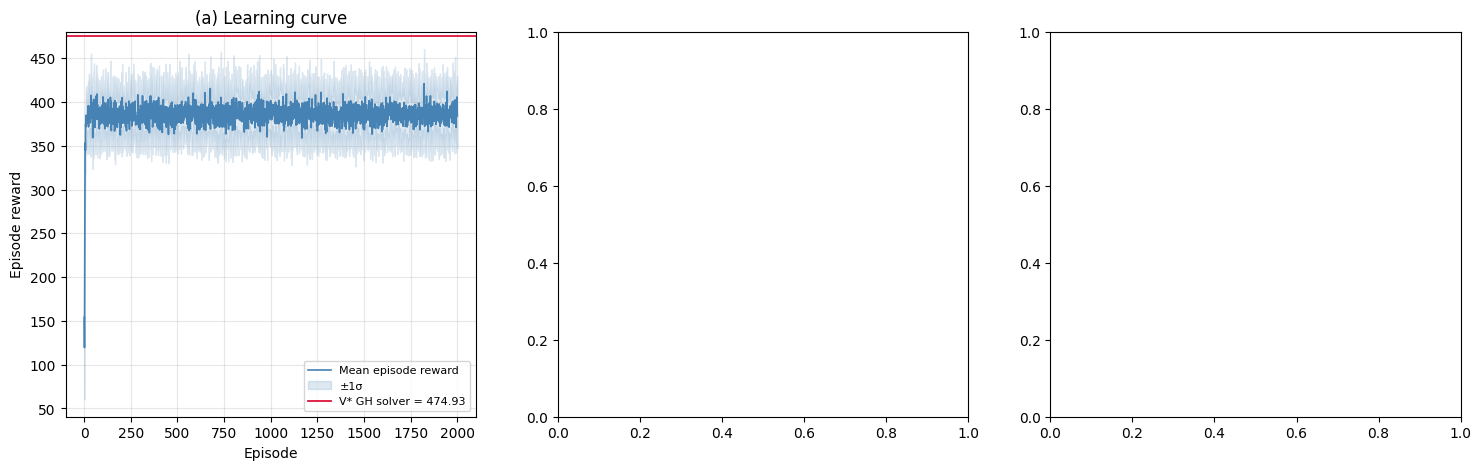

In [6]:
slopes = plot_all(
    vpi_matrix = vpi_matrix,
    v_star_gh  = v_star_gh,
    fit_start  = FIT_START,
)

print('\n── Regret slope summary ──────────────────────────────────')
for name, sl in slopes.items():
    tag = '  <- compare with paper' if 'GH' in name else ''
    print(f'  {name:<28s}  alpha = {sl:.4f}{tag}')
print(f'  Theoretical worst-case bound     alpha = 0.7500  (Theorem 5.19)')
print(f'  Paper Figure 3(b) reports        alpha ~= 0.6900')

gh_slope = slopes.get('GH solver (paper ref)', float('nan'))
status = 'sublinear regret confirmed' if gh_slope < 0.75 else 'slope >= 0.75'
print(f'\n  {status}  (slope = {gh_slope:.4f})')


## Optional — manual regret inspection

In [12]:
# Compute regret arrays directly if you want to inspect or replot manually
cum_mean, cum_lo, cum_hi = cumulative_regret(vpi_matrix, v_star_gh)
slope, intercept, r2     = regret_slope(cum_mean, fit_start=FIT_START)

print(f"Cumulative regret at K={N_EPS}: {cum_mean[-1]:.1f}")
print(f"Log-log slope α = {slope:.4f}  (R² = {r2:.4f})")

Cumulative regret at K=2000: 274298.6
Log-log slope α = 0.9962  (R² = 1.0000)
